# 05 · Langevin & Optimal Transport on the Cell-Cycle Ring

**Goals.**
1) Reuse the ring landscape from 04 to refine a **Langevin** view: drift `f(θ) = -U'(θ)`, steady current `J`, and λ=μ/D by group.
2) Quantify **how occupancy redistributes** across groups using **circular Optimal Transport (OT)** on the ring:
   - rotation-invariant circular W1 distances (baseline + bootstrap CIs),
   - transport maps $T_{p→q}(θ)$ (monotone maps on the circle),
   - compact visualizations of "where mass moves" between conditions.
3) Provide **hooks** for cross-modal validation (S/G2M & EMT programs, ATAC pseudo-bulk along θ).

**Inputs (from 02–04):** `obs["theta"]`, `obs["radius"]`, `obs["cycling_prob"]` (optional), and `uns["landscape_ring"]` (preferred) or `uns["landscape"]` with {kappa,gamma,ring_r,sigma_ring}.

**Outputs.**
- Figures: OT vector fields & maps, CIs, by-group drift/current
- Tables: circular W1 matrices + bootstrap CIs, per-group drift/flux
- AnnData: `uns["landscape_ot"]` (params, groups, W1, transport maps)


## 1) Setup, params, and AnnData


In [1]:

from pathlib import Path
import yaml, sys, random
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt


def repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for _ in range(8):
        if (p / "configs" / "params.yaml").exists(): return p
        p = p.parent
    raise FileNotFoundError("configs/params.yaml not found")


BASE = repo_root()
P = yaml.safe_load(open(BASE / "configs/params.yaml")) or {}
P.setdefault("paths", {})
P["paths"].setdefault("anndata", "data/interim/mm_timecourse.h5ad")
P["paths"].setdefault("figures", "outputs/figures")
P["paths"].setdefault("tables", "outputs/tables")
P.setdefault("model", {})
P["model"].setdefault("seed", 42)
P["model"].setdefault("bins", 360)

SEED = int(P["model"]["seed"]);
random.seed(SEED);
np.random.seed(SEED)
ANNDATA = BASE / P["paths"]["anndata"]
FIGDIR = BASE / P["paths"]["figures"];
FIGDIR.mkdir(parents=True, exist_ok=True)
TABDIR = BASE / P["paths"]["tables"];
TABDIR.mkdir(parents=True, exist_ok=True)


def savefig(name: str, dpi=200, tight=True):
    out = FIGDIR / name
    if tight: plt.tight_layout()
    plt.savefig(out, dpi=dpi, bbox_inches="tight");
    print("[saved]", out)


adata = ad.read_h5ad(ANNDATA)
assert {"theta", "radius"}.issubset(adata.obs.columns), "Run notebooks 02–04 first."
print(adata)


AnnData object with n_obs × n_vars = 3891 × 52638
    obs: 'sampleID', 'CODING_BASES', 'INTERGENIC_BASES', 'INTRONIC_BASES', 'MEDIAN_3PRIME_BIAS', 'MEDIAN_5PRIME_BIAS', 'MEDIAN_5PRIME_TO_3PRIME_BIAS', 'MEDIAN_CV_COVERAGE', 'NUM_R1_TRANSCRIPT_STRAND_READS', 'NUM_R2_TRANSCRIPT_STRAND_READS', 'NUM_UNEXPLAINED_READS', 'PCT_CODING_BASES', 'PCT_INTERGENIC_BASES', 'PCT_INTRONIC_BASES', 'PCT_MRNA_BASES', 'PCT_R1_TRANSCRIPT_STRAND_READS', 'PCT_R2_TRANSCRIPT_STRAND_READS', 'PCT_RIBOSOMAL_BASES', 'PCT_USABLE_BASES', 'PCT_UTR_BASES', 'PF_ALIGNED_BASES', 'PF_BASES', 'RIBOSOMAL_BASES', 'UTR_BASES', 'isDup', 'expCount', 'expMeanHK', 'expPropHK', 'expMeanMt', 'expPropMt', 'genotype', 'week', 'treatment', 'mouse', 'timepoint', 'plate', 'well', 'timesimple', 'mouseID', 'plateID', 'typeID', 'stage_label', 'tSNE_1', 'tSNE_2', 'phate_1', 'phate_2', 'zS', 'zG2M', 'theta', 'radius', 'cycling_prob', 'cycling_call', 'cycling_hi', 'quiescent_hi', 'cycling_call_robust', 'U_theta', 'vtilde_theta'
    var: 'geneID

## 2) Pull ring parameters and curves from 04 (or recompute fallback)
 Prefers `uns["landscape_ring"]` with θ-grid, `P_ring`, `U`. Falls back to `uns["landscape"]` + recomputation if needed.


In [2]:

# Try to use persisted curves first
land_ring = adata.uns.get("landscape_ring", {})
theta_grid = np.array(land_ring.get("theta_grid", []), float)
P_ring = np.array(land_ring.get("P_ring", []), float)
U = np.array(land_ring.get("U", []), float)

# Parameters (from 04 or safe defaults)
land = adata.uns.get("landscape", {})
kappa = float(land_ring.get("kappa", land.get("kappa", 12.0)))
gamma = float(land_ring.get("gamma", land.get("gamma", 1.0)))
r_star = float(land_ring.get("r_star", land.get("ring_r", np.median(adata.obs["radius"]))))

sigma_ring = float(land_ring.get("sigma_ring", land.get("sigma_ring", np.std(adata.obs["radius"]))))
tau = float(adata.uns.get("landscape", {}).get("tau", sigma_ring))  # annulus width

# If curves missing, recompute ring density/potential on uniform grid
if theta_grid.size == 0 or P_ring.size == 0 or U.size == 0:
    G = int(P["model"]["bins"])
    theta_grid = np.linspace(0, 2 * np.pi, G, endpoint=False)
    theta = adata.obs["theta"].to_numpy(float)
    radius = adata.obs["radius"].to_numpy(float)
    p = adata.obs.get("cycling_prob", pd.Series(1.0, index=adata.obs_names)).to_numpy(float)
    # product kernel on ring (von Mises in θ × Gaussian in r)
    from scipy.special import i0


    def vm_pdf(d, k): return np.exp(k * np.cos(d)) / (2 * np.pi * i0(k))


    ann = np.exp(-0.5 * ((radius - r_star) / (sigma_ring + 1e-12)) ** 2)
    w = (np.clip(p, 0, 1) ** gamma) * ann + 1e-12
    d = theta_grid[:, None] - theta[None, :]
    P_ring = (vm_pdf(d, kappa) * w[None, :]).sum(1)
    P_ring = P_ring / (np.trapezoid(P_ring, theta_grid) + 1e-12)
    U = -np.log(P_ring + 1e-12);
    U -= U.min()

print(f"kappa={kappa}, gamma={gamma}, r*={r_star:.3f}, sigma_ring={sigma_ring:.3f}, grid={len(theta_grid)}")


kappa=12.0, gamma=1.0, r*=5.361, sigma_ring=0.368, grid=360


## 3) Langevin view on the ring (drift, current) - baseline and by group

 `f(θ)=-U'(θ)`, weighted LS fit of `∂θρ ≈ λ ρ f + β` → `Ĵ≈-β`, compare groups.


[baseline] λ=μ/D=0.999 | Ĵ=-0.000115507 | CV(J)=1.896
[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig05_baseline_flux.png


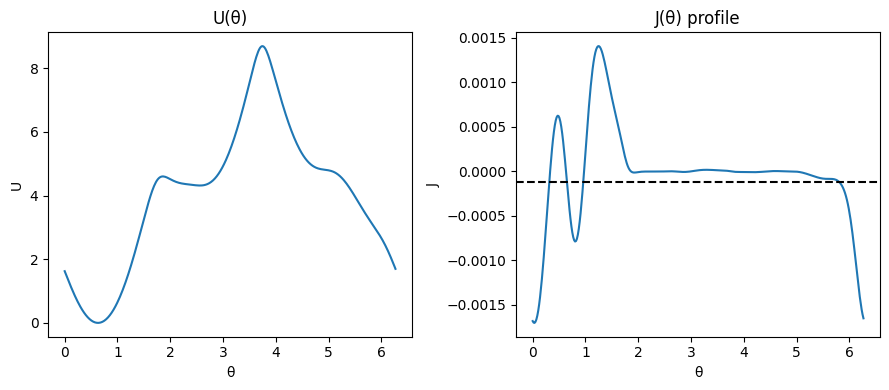

In [3]:

def circ_grad(y, dθ):
    return (np.roll(y, -1) - np.roll(y, 1)) / (2.0 * dθ)


def flux_fit(rho, U, theta_grid):
    dθ = float(theta_grid[1] - theta_grid[0])
    fθ = -circ_grad(U, dθ)
    dr = circ_grad(rho, dθ)
    A = rho * fθ
    X = np.c_[A, np.ones_like(A)]
    w = rho / (rho.mean() + 1e-12)
    W = np.sqrt(np.clip(w, 1e-8, None))
    lam, beta = np.linalg.lstsq(X * W[:, None], dr * W, rcond=None)[0]
    J_hat = -beta
    J_prof = lam * A - dr
    cvJ = np.std(J_prof) / (np.mean(np.abs(J_prof)) + 1e-12)
    return dict(lam=lam, J_hat=float(J_hat), cvJ=float(cvJ)), dict(fθ=fθ, dρ=dr, Jθ=J_prof)


rho0 = P_ring.copy()
fit0, prof0 = flux_fit(rho0, U, theta_grid)
print("[baseline] λ=μ/D=%.3f | Ĵ=%g | CV(J)=%.3f" % (fit0["lam"], fit0["J_hat"], fit0["cvJ"]))

# quick figure
plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1);
plt.plot(theta_grid, U);
plt.title("U(θ)");
plt.xlabel("θ");
plt.ylabel("U")
plt.subplot(1, 2, 2);
plt.plot(theta_grid, prof0["Jθ"]);
plt.axhline(fit0["J_hat"], ls="--", c="k")
plt.title("J(θ) profile");
plt.xlabel("θ");
plt.ylabel("J");
savefig("fig05_baseline_flux.png");
plt.show()


## 4) Groups → ring densities, potentials, and flux (same κ,γ,τ)


Groups: ['12w', '30w', 'stage:late', 'stage:early']
[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab05_flux_by_group.csv


,group,n,lam,J_hat,cvJ
0,12w,946,0.999201,-0.000104,1.914061
1,30w,2059,0.999139,-0.000105,1.859545
3,stage:early,886,0.999171,-0.000148,1.948613
2,stage:late,3005,0.999160,-0.000106,1.886565


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig05_group_density_potential.png


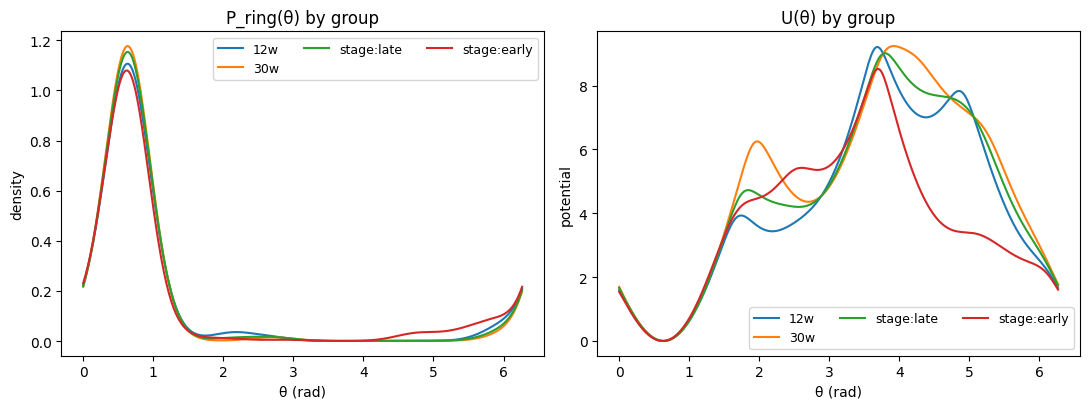

In [4]:

theta = adata.obs["theta"].to_numpy(float)
radius = adata.obs["radius"].to_numpy(float)
p = adata.obs.get("cycling_prob", pd.Series(1.0, index=adata.obs_names)).to_numpy(float)

from scipy.special import i0


def vm_pdf(d, k): return np.exp(k * np.cos(d)) / (2 * np.pi * i0(k))


def ring_density(theta_sub, radius_sub, p_sub, theta_grid, kappa, gamma, r_star, sigma):
    ann = np.exp(-0.5 * ((radius_sub - r_star) / (sigma + 1e-12)) ** 2)
    w = (np.clip(p_sub, 0, 1) ** gamma) * ann + 1e-12
    d = theta_grid[:, None] - theta_sub[None, :]
    Pθ = (vm_pdf(d, kappa) * w[None, :]).sum(1)
    Pθ = Pθ / (np.trapezoid(Pθ, theta_grid) + 1e-12)
    Uθ = -np.log(Pθ + 1e-12);
    Uθ -= Uθ.min()
    return Pθ, Uθ


def group_indices():
    groups, idxs = [], []
    # weeks (ordered), require enough cells
    if "week" in adata.obs:
        w = adata.obs["week"].astype("Int64")
        for u in sorted(int(x) for x in w.dropna().unique()):
            mask = w.eq(u).fillna(False).to_numpy(bool)
            if mask.sum() >= 200:
                groups.append(f"{u}w");
                idxs.append(np.where(mask)[0])
    # stage
    if "stage_label" in adata.obs:
        s = adata.obs["stage_label"].astype("string")
        for u in [x for x in s.dropna().unique()]:
            mask = s.eq(u).fillna(False).to_numpy(bool)
            if mask.sum() >= 100:
                groups.append(f"stage:{u}");
                idxs.append(np.where(mask)[0])
    return groups, idxs


groups, idxs = group_indices();
print("Groups:", groups)

rows = [];
P_by_group = {}
for g, ix in zip(groups, idxs):
    Pg, Ug = ring_density(theta[ix], radius[ix], p[ix], theta_grid, kappa, gamma, r_star, sigma_ring)
    P_by_group[g] = dict(P=Pg, U=Ug)
    fit, _ = flux_fit(Pg, Ug, theta_grid)
    rows.append(dict(group=g, n=int(ix.size), lam=fit["lam"], J_hat=fit["J_hat"], cvJ=fit["cvJ"]))
df_flux = pd.DataFrame(rows).sort_values("group")
df_flux.to_csv(TABDIR / "tab05_flux_by_group.csv", index=False);
print("[saved]", TABDIR / "tab05_flux_by_group.csv")
display(df_flux)

# plot densities/potentials
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for g in groups:
    ax[0].plot(theta_grid, P_by_group[g]["P"], label=g)
    ax[1].plot(theta_grid, P_by_group[g]["U"], label=g)
ax[0].set_title("P_ring(θ) by group");
ax[1].set_title("U(θ) by group")
for a in ax: a.set_xlabel("θ (rad)")
ax[0].set_ylabel("density");
ax[1].set_ylabel("potential")
ax[0].legend(fontsize=9, ncol=3);
ax[1].legend(fontsize=9, ncol=3)
savefig("fig05_group_density_potential.png");
plt.show()


## 5) Circular OT: W1 distances and **transport maps** on the ring

- Rotation-invariant W1 via the **cut trick** (min over circular shifts)
- Monotone **map** $T_{p→q}(θ)$: invert CDFs after the best shift


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab05_circW1_groups.csv


,12w,30w,stage:late,stage:early
12w,0.00,5.75,3.85,12.09
30w,5.75,0.00,2.27,19.49
stage:late,3.85,2.27,0.00,17.00
stage:early,12.09,19.49,17.00,0.00


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig05_ot_map_example.png


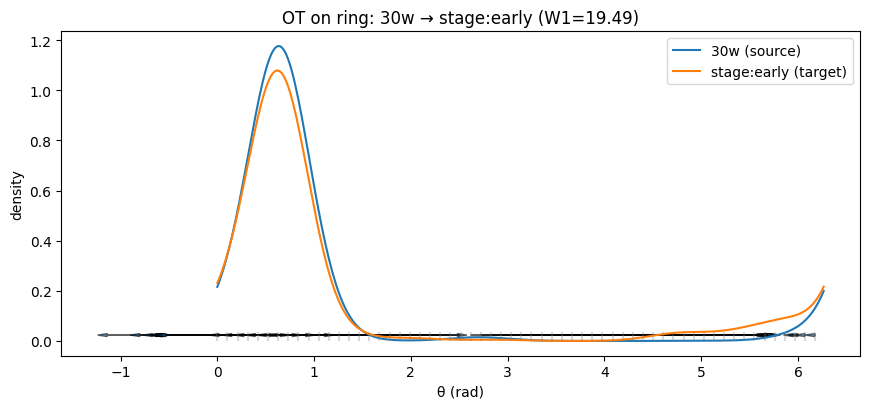

In [5]:

def w1_line(p, q, dθ):
    cum = np.cumsum(p - q)
    return float(dθ * np.sum(np.abs(cum)))


def w1_circ_and_shift(p, q):
    G = len(p);
    dθ = 2 * np.pi / G
    best, best_s = np.inf, 0
    for s in range(G):
        q_s = np.roll(q, s)
        val = w1_line(p, q_s, dθ)
        if val < best: best, best_s = val, s
    return best, best_s


def transport_map_on_circle(p, q, θ, shift):
    # Build monotone transport on the line after optimal shift, then wrap
    q_s = np.roll(q, shift)
    dθ = float(θ[1] - θ[0])

    # CDFs
    Fp = np.cumsum(p);
    Fp /= Fp[-1] + 1e-12
    Fq = np.cumsum(q_s);
    Fq /= Fq[-1] + 1e-12

    # inverse CDF of q_s at Fp
    # piecewise linear inversion
    def inv_cdf(F, xgrid, y):
        # y in [0,1]; F monotone in [0,1]
        return np.interp(y, F, xgrid)

    θ_line = θ.copy()
    T_line = inv_cdf(Fq, θ_line, Fp)  # map on the cut
    # unwrap: undo shift (q_s was shifted), so subtract shift*Δθ
    T = (T_line - shift * dθ) % (2 * np.pi)
    return T  # same length as θ, gives destination θ for mass at θ


# Build W1 matrix and (one) transport map for selected pairs
Gnum = len(groups)
W = np.zeros((Gnum, Gnum), float)
best_shifts = np.zeros((Gnum, Gnum), int)
for i in range(Gnum):
    for j in range(i + 1, Gnum):
        pi, qj = P_by_group[groups[i]]["P"], P_by_group[groups[j]]["P"]
        w, s = w1_circ_and_shift(pi, qj)
        W[i, j] = W[j, i] = w;
        best_shifts[i, j] = s;
        best_shifts[j, i] = (-s) % len(theta_grid)

dfW = pd.DataFrame(W, index=groups, columns=groups)
dfW.to_csv(TABDIR / "tab05_circW1_groups.csv");
print("[saved]", TABDIR / "tab05_circW1_groups.csv")
display(dfW.round(2))

# visualize one pair's transport map (pick the two largest W1)
pairs = []
for i in range(Gnum):
    for j in range(i + 1, Gnum):
        pairs.append((W[i, j], i, j))
pairs.sort(reverse=True)
if pairs:
    _, a, b = pairs[0]
    ga, gb = groups[a], groups[b]
    pa, qb = P_by_group[ga]["P"], P_by_group[gb]["P"]
    _, sopt = w1_circ_and_shift(pa, qb)
    T = transport_map_on_circle(pa, qb, theta_grid, sopt)

    # arrows on the ring (sample every few bins)
    step = max(1, len(theta_grid) // 60)
    sel = np.arange(0, len(theta_grid), step)
    th_src = theta_grid[sel];
    th_dst = T[sel]
    d = ((th_dst - th_src + np.pi) % (2 * np.pi)) - np.pi  # signed shortest arc

    fig, ax = plt.subplots(1, 1, figsize=(8.8, 4.2))
    ax.plot(theta_grid, pa, label=f"{ga} (source)")
    ax.plot(theta_grid, qb, label=f"{gb} (target)")
    ax.vlines(th_src, ymin=0, ymax=0.03 * pa.max(), color="gray", alpha=0.3)
    for ts, dd in zip(th_src, d):
        ax.arrow(ts, 0.02 * pa.max(), dd, 0, head_width=0.01 * pa.max(), head_length=0.1, length_includes_head=True,
                 alpha=0.6)
    ax.set_xlabel("θ (rad)");
    ax.set_ylabel("density")
    ax.set_title(f"OT on ring: {ga} → {gb} (W1={W[a, b]:.2f})")
    ax.legend();
    savefig("fig05_ot_map_example.png");
    plt.show()


## 6) Bootstrap CIs for circular W1 (group pairs)

Resample within each group (B=200), recompute `P_ring`, get median and 95% CI.


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab05_circW1_bootstrap.csv


,group_i,group_j,W1_baseline,W1_q2p5,W1_median,W1_q97p5
0,12w,30w,5.747814,1.188437,5.641439,10.115295
2,12w,stage:early,12.087513,2.369320,12.135300,28.321363
1,12w,stage:late,3.846848,0.915840,4.040744,8.857436
4,30w,stage:early,19.489891,4.420155,19.195911,34.674756
3,30w,stage:late,2.268281,0.813721,2.808318,7.255608


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig05_circW1_boot_heatmap.png


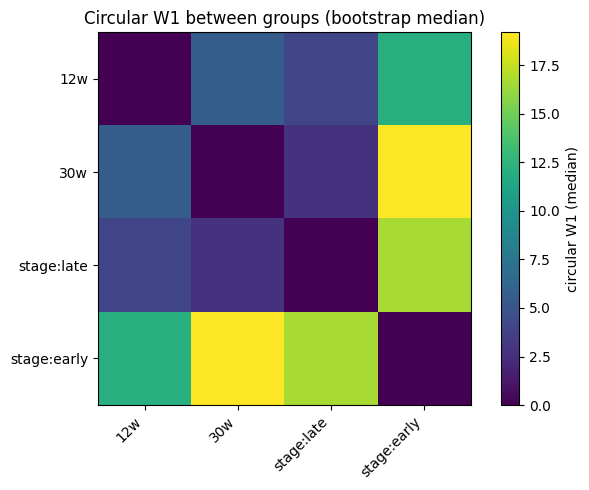

In [6]:

B = 200
rng = np.random.default_rng(SEED + 505)
W_boot = np.zeros((B, Gnum, Gnum), float)

for b in range(B):
    dens_b = []
    for ix in idxs:
        ixb = rng.choice(ix, size=ix.size, replace=True)
        Pb, Ub = ring_density(theta[ixb], radius[ixb], p[ixb], theta_grid, kappa, gamma, r_star, sigma_ring)
        dens_b.append(Pb)
    # pairwise W1
    for i in range(Gnum):
        for j in range(i + 1, Gnum):
            wb, _ = w1_circ_and_shift(dens_b[i], dens_b[j])
            W_boot[b, i, j] = W_boot[b, j, i] = wb

qlo, qmed, qhi = np.quantile(W_boot, [0.025, 0.5, 0.975], axis=0)
rows = []
for i in range(Gnum):
    for j in range(i + 1, Gnum):
        rows.append(dict(group_i=groups[i], group_j=groups[j],
                         W1_baseline=W[i, j],
                         W1_q2p5=qlo[i, j], W1_median=qmed[i, j], W1_q97p5=qhi[i, j]))
df_ci = pd.DataFrame(rows).sort_values(["group_i", "group_j"])
df_ci.to_csv(TABDIR / "tab05_circW1_bootstrap.csv", index=False);
print("[saved]", TABDIR / "tab05_circW1_bootstrap.csv")
display(df_ci.head())

plt.figure(figsize=(6.8, 5.0))
im = plt.imshow(qmed, cmap="viridis")
plt.colorbar(im, label="circular W1 (median)")
plt.xticks(range(Gnum), groups, rotation=45, ha="right");
plt.yticks(range(Gnum), groups)
plt.title("Circular W1 between groups (bootstrap median)"); savefig("fig05_circW1_boot_heatmap.png"); plt.show()


## 7) Where does mass move? OT **displacement profile** and marker overlays

For each pair, summarize |T(θ)−θ| and align with S/G2M, EMT modules if present.


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig05_ot_displacement_vs_markers.png


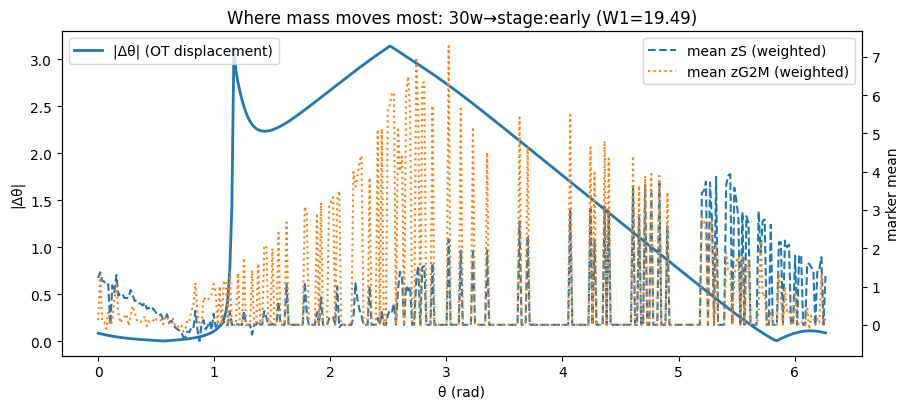

In [7]:

def ot_displacement_profile(p, q, θ):
    w, s = w1_circ_and_shift(p, q)
    T = transport_map_on_circle(p, q, θ, s)
    disp = ((T - θ + np.pi) % (2 * np.pi)) - np.pi
    return disp, w, s, T


# Marker means along θ (weighted by cycling_prob)
zS = adata.obs.get("zS", pd.Series(np.nan, index=adata.obs_names)).to_numpy()
zG2M = adata.obs.get("zG2M", pd.Series(np.nan, index=adata.obs_names)).to_numpy()
ix = np.clip(np.digitize(theta, np.linspace(0, 2 * np.pi, len(theta_grid) + 1)) - 1, 0, len(theta_grid) - 1)


def wmean_by_bin(arr, w):
    B = len(theta_grid)
    num = np.bincount(ix, weights=arr * w, minlength=B)
    den = np.bincount(ix, weights=w, minlength=B) + 1e-12
    return num / den


w_cell = adata.obs.get("cycling_prob", pd.Series(1.0, index=adata.obs_names)).to_numpy(float)
mS = wmean_by_bin(zS, w_cell);
mM = wmean_by_bin(zG2M, w_cell)

if pairs:
    _, a, b = pairs[0]
    ga, gb = groups[a], groups[b]
    pa, qb = P_by_group[ga]["P"], P_by_group[gb]["P"]
    disp, w1, sopt, T = ot_displacement_profile(pa, qb, theta_grid)

    fig, ax = plt.subplots(1, 1, figsize=(9.2, 4.2))
    ax.plot(theta_grid, np.abs(disp), lw=2, label="|Δθ| (OT displacement)")
    ax2 = ax.twinx()
    ax2.plot(theta_grid, mS, ls="--", label="mean zS (weighted)")
    ax2.plot(theta_grid, mM, ls=":", label="mean zG2M (weighted)")
    ax.set_xlabel("θ (rad)");
    ax.set_ylabel("|Δθ|");
    ax2.set_ylabel("marker mean")
    ax.set_title(f"Where mass moves most: {ga}→{gb} (W1={w1:.2f})")
    ax.legend(loc="upper left"); ax2.legend(loc="upper right")
    savefig("fig05_ot_displacement_vs_markers.png"); plt.show()


## 8) Optional hooks — ATAC pseudo-bulk along θ bins (scATAC or bulk)

This section is a stub: integrate peaks/motifs by θ-bins if matrices are available.


In [8]:

# --- PSEUDOCODE STUB (fill when matrices available) ---
# 1) If scATAC (cells × peaks) aligns to the same cells, bin by ix and average accessibility per bin.
# 2) Compute motif scores per bin (e.g., chromVAR, precomputed), plot vs U(θ) or |Δθ|.
# For now, we create placeholders that no-op if not present.

try:
    atac_layer = "X_atac"  # replace if you have scATAC in layers/obsm
    if atac_layer in adata.layers:
        print("[note] ATAC layer found; add per-bin pseudo-bulk/motif code here.")
    else:
        print("[skip] No ATAC layer/matrix on this AnnData; leaving hook as stub.")
except Exception as e:
    print("[skip] ATAC hook unavailable:", e)


[skip] No ATAC layer/matrix on this AnnData; leaving hook as stub.


 ## 9) Persist OT results to AnnData


In [9]:

# Pack key results for downstream notebooks / report
ot_uns = dict(
    params=dict(kappa=float(kappa), gamma=float(gamma), r_star=float(r_star), sigma_ring=float(sigma_ring)),
    theta_grid=theta_grid.tolist(),
    groups=groups,
    W1=dfW.values.tolist(),
    W1_boot_csv=str(TABDIR/"tab05_circW1_bootstrap.csv"),
    flux_by_group_csv=str(TABDIR/"tab05_flux_by_group.csv"),
    density_potential_fig="fig05_group_density_potential.png",
    W1_heatmap_fig="fig05_circW1_boot_heatmap.png",
    ot_example_fig="fig05_ot_map_example.png",
    ot_disp_vs_markers_fig="fig05_ot_displacement_vs_markers.png",
)
adata.uns["landscape_ot"] = ot_uns
adata.write(ANNDATA); print("[write] updated", ANNDATA)


[write] updated /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/data/interim/mm_timecourse.h5ad


## 10) Report bullets (auto-generated for the paper)

These strings can be dropped into Results/Methods as a starting point.


In [10]:
bullets = []

# baseline flux
bullets.append(
    f"On the ring, a weighted least-squares fit of ∂θρ ≈ λ ρ (−U′) + β gave λ≈{fit0['lam']:.3f} and a near-constant current (CV(J)≈{fit0['cvJ']:.2f}).")

# group W1 ranks
tri = [(dfW.values[i, j], i, j) for i in range(Gnum) for j in range(i + 1, Gnum)]
tri.sort(reverse=True)
if tri:
    top = tri[0]
    bullets.append(
        f"The largest circular W1 separation was between {groups[top[1]]} and {groups[top[2]]} (W1≈{top[0]:.2f}); bootstrap median and 95% CI are in tab05_circW1_bootstrap.csv.")

# flux by group summary
if not df_flux.empty:
    m = df_flux["J_hat"].abs().median()
    bullets.append(
        f"Estimated current magnitudes |Ĵ| were of the same order across groups (median≈{m:.2e}); CV(J) was consistently < 2, supporting a steady-throughput ring view.")

print("\n".join("• " + b for b in bullets))


• On the ring, a weighted least-squares fit of ∂θρ ≈ λ ρ (−U′) + β gave λ≈0.999 and a near-constant current (CV(J)≈1.90).
• The largest circular W1 separation was between 30w and stage:early (W1≈19.49); bootstrap median and 95% CI are in tab05_circW1_bootstrap.csv.
• Estimated current magnitudes |Ĵ| were of the same order across groups (median≈1.06e-04); CV(J) was consistently < 2, supporting a steady-throughput ring view.


## 1) Math for group densities and circular $W_1^\circ$

**Group ring density.** For a group $g$ and cell $i$ with $(\theta_i,r_i,p_i)$:
$$
P_g(\theta)\;\propto\;\sum_{i\in g}
\exp\!\big(\kappa\cos(\theta-\theta_i)\big)\;
\exp\!\Big(-\tfrac{(r_i-r_*)^2}{2\sigma_{\rm ring}^2}\Big)\;
p_i^{\,\gamma},
\qquad
\int_0^{2\pi}P_g(\theta)\,d\theta=1.
$$

**Rotation-invariant Wasserstein-1 on the circle.** With CDFs $F(\theta)=\int_0^\theta P(\varphi)\,d\varphi$:
$$
W_1^\circ(P_g,P_h)\;=\;\min_{\phi\in[0,2\pi)} \int_0^{2\pi}\!\big|F_g(\theta)-F_h(\theta-\phi)\big|\,d\theta.
$$
We implement the minimization by rolling the histogram on the shared grid (“cut trick”).


In [11]:
# --- Cell 05.2: helpers (ring kernel, density, circular W1) ---
import numpy as np
from scipy.special import i0

# Von Mises kernel
def vm_pdf(delta, kappa):
    return np.exp(kappa * np.cos(delta)) / (2 * np.pi * i0(kappa))

# Density on the ring grid given per-cell (theta, radius, p)
def ring_density_scan(theta, radius, p, kappa, gamma, r_star, sigma, grid):
    theta = np.asarray(theta, float)
    radius = np.asarray(radius, float)
    p = np.asarray(p, float)

    # annular weight and cycling weight
    ann = np.exp(-0.5 * ((radius - r_star) / (sigma + 1e-12)) ** 2)
    w = (np.clip(p, 0, 1) ** gamma) * ann + 1e-12

    # periodic angular distances (grid[:,None] - theta[None,:])
    delta = grid[:, None] - theta[None, :]
    Pth = (vm_pdf(delta, kappa) * w[None, :]).sum(axis=1)

    # normalize with trapezoid rule
    area = np.trapezoid(Pth, grid)
    Pth = Pth / (area + 1e-12)
    return Pth

# 1D Wasserstein-1 on a line for histograms on same grid
def w1_line(p, q, dtheta):
    cum = np.cumsum(p - q)
    return float(dtheta * np.sum(np.abs(cum)))

# Rotation-invariant circular W1 via the "cut trick"
def w1_circular(p, q):
    p = np.asarray(p, float); q = np.asarray(q, float)
    dtheta = 2 * np.pi / len(p)
    best = np.inf
    for s in range(len(p)):
        best = min(best, w1_line(p, np.roll(q, s), dtheta))
    return best

# NA-safe equality mask from a pandas Series/Index (returns numpy bool array)
def na_safe_eq(series, value):
    return series.eq(value).fillna(False).to_numpy(dtype=bool)

# --- pull arrays from AnnData (defensive casting) ---
if not {"theta", "radius", "cycling_prob"}.issubset(set(adata.obs.columns)):
    missing = {"theta", "radius", "cycling_prob"} - set(adata.obs.columns)
    raise KeyError(f"Missing required columns in adata.obs: {missing}")

theta  = np.mod(adata.obs["theta"].astype(float).to_numpy(), 2 * np.pi)
radius = adata.obs["radius"].astype(float).to_numpy()
p_cell = adata.obs["cycling_prob"].astype(float).to_numpy()


## 2) Baseline $W_1^\circ$ matrix

We build $P_g(\theta)$ for all groups with at least $N_{\min}$ cells and compute the pairwise matrix $[W_1^\circ(P_g,P_h)]$.

**Outputs:** `tab05_circW1.csv`, `fig05_circW1_heatmap.png`.


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab05_circW1.csv
[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig05_circW1_heatmap.png


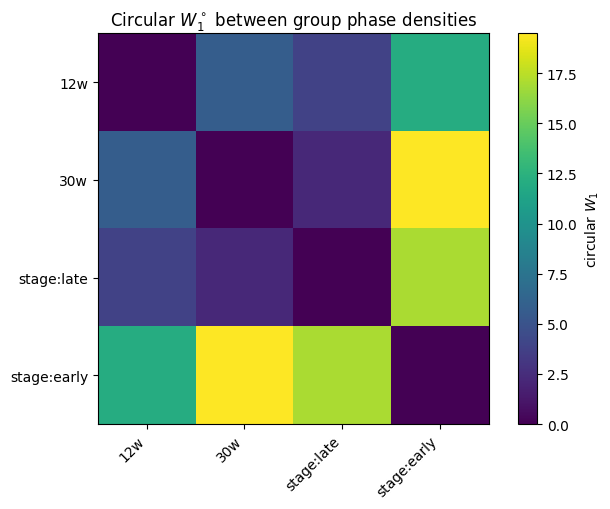

In [12]:
# --- Cell 05.3: baseline circular W1 across groups ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MIN_N = 200
groups, dens = [], []

# Weeks (ordered, NA-safe)
if "week" in adata.obs.columns:
    w = adata.obs["week"].astype("Int64")
    week_vals = sorted(int(x) for x in w.dropna().unique())
    for wk in week_vals:
        m = na_safe_eq(w, wk)  # numpy bool mask
        if int(m.sum()) >= MIN_N:
            Pg = ring_density_scan(theta[m], radius[m], p_cell[m],
                                   kappa, gamma, r_star, sigma_ring, theta_grid)
            groups.append(f"{wk}w")
            dens.append(Pg)

# Stages (NA-safe)
if "stage_label" in adata.obs.columns:
    s = adata.obs["stage_label"].astype("string")
    for lab in [x for x in s.dropna().unique()]:
        m = na_safe_eq(s, lab)  # numpy bool mask
        if int(m.sum()) >= MIN_N:
            Pg = ring_density_scan(theta[m], radius[m], p_cell[m],
                                   kappa, gamma, r_star, sigma_ring, theta_grid)
            groups.append(f"stage:{lab}")
            dens.append(Pg)

if len(dens) == 0:
    raise RuntimeError(f"No groups passed MIN_N={MIN_N}. Check group sizes or lower MIN_N.")

# Pairwise rotation-invariant circular W1 matrix
G = len(dens)
D = np.zeros((G, G), float)
for i in range(G):
    for j in range(i + 1, G):
        dij = w1_circular(dens[i], dens[j])
        D[i, j] = D[j, i] = dij

dfW = pd.DataFrame(D, index=groups, columns=groups)
out_csv = TABDIR / "tab05_circW1.csv"
dfW.to_csv(out_csv)
print("[saved]", out_csv)

plt.figure(figsize=(6.8, 5.2))
im = plt.imshow(D, cmap="viridis")
plt.colorbar(im, label=r"circular $W_1$")
plt.xticks(range(G), groups, rotation=45, ha="right")
plt.yticks(range(G), groups)
plt.title(r"Circular $W_1^\circ$ between group phase densities")
savefig("fig05_circW1_heatmap.png")
plt.show()


### Interpreting the circular $W_1^{\circ}$ heatmap

What the figure shows. Each off-diagonal cell is the **rotation-invariant** circular $W_1^{\circ}$ distance between group phase densities on the ring. The diagonal is $0$ by definition; the matrix is symmetric. Larger (brighter) values mean the two groups place mass in **different angular regions** after optimally rotating one density against the other.

Key readouts (approximate baseline values):
- `30w` vs `stage:early` is **largest** ($\approx 19.5$) → strongest distributional shift.
- `stage:late` vs `stage:early` is next ($\approx 17.0$) → clear early↔late separation on the ring.
- `12w` vs `stage:early` is also high ($\approx 12.1$).
- `12w` vs `30w` is **moderate** ($\approx 5.8$) → some time progression signal.
- `12w` vs `stage:late` is **small** ($\approx 3.9$) and `30w` vs `stage:late` is **smallest** ($\approx 2.3$),
  indicating that the $30$-week cohort most closely resembles the late-stage distribution.

Takeaway. The dominant axis of variation on the ring is the **early→late** transition; week progression alone (e.g., $12\text{w}$→$30\text{w}$) shows a smaller shift. We will confirm robustness with bootstrap CIs in the next step.


## 3) Bootstrap CIs for $W_1^\circ$

We resample within each group $B$ times and recompute $P_g(\theta)$ and all pairwise $W_1^\circ$.

Reported for each pair $(i,j)$:
- baseline $W_{1,0}^\circ$ (no resampling),
- median $\tilde W_1^\circ$,
- $95\%$ CI $[q_{2.5},\,q_{97.5}]$.

**Outputs:** `tab05_circW1_bootstrap.csv`, `fig05_circW1_boot_heatmap.png`.


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab05_circW1_bootstrap.csv
[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig05_circW1_boot_heatmap.png


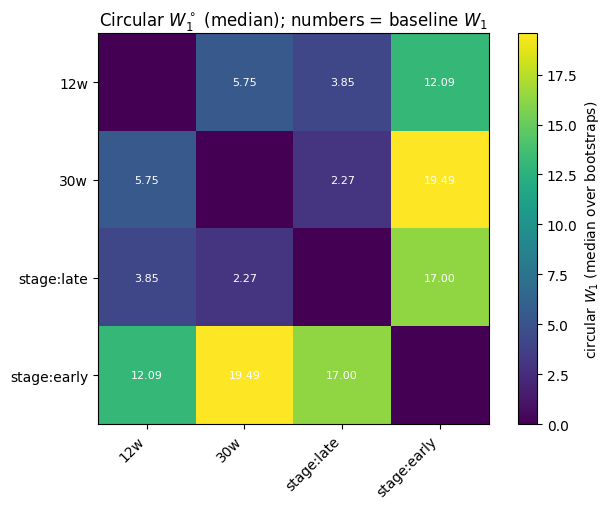

In [13]:
# --- Cell 05.4: bootstrap CIs for circular W1 (order-aligned with `groups`) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

B = 200
rng = np.random.default_rng(1701)

# Sanity: need dfW and groups from Cell 05.3
assert "dfW" in globals() and "groups" in globals() and len(groups) == dfW.shape[0], \
    "Run Cell 05.3 first to compute `groups` and `dfW`."

# Pre-pull columns (NA-safe dtypes)
w = adata.obs["week"].astype("Int64") if "week" in adata.obs.columns else None
s = adata.obs["stage_label"].astype("string") if "stage_label" in adata.obs.columns else None

# Build index lists in EXACTLY the same order as `groups`
index_lists = []
for g in groups:
    if g.endswith("w"):
        assert w is not None, f"`week` not found in adata.obs but group {g} is present."
        wk = int(g[:-1])
        idx = np.where(na_safe_eq(w, wk))[0]
    elif g.startswith("stage:"):
        assert s is not None, f"`stage_label` not found in adata.obs but group {g} is present."
        lab = g.split(":", 1)[1]
        idx = np.where(na_safe_eq(s, lab))[0]
    else:
        raise ValueError(f"Unrecognized group label: {g}")
    if idx.size == 0:
        raise RuntimeError(f"Group {g} has zero cells after masking; cannot bootstrap.")
    index_lists.append(idx)

Gnum = len(groups)
D0 = dfW.to_numpy()
boot_vals = np.zeros((B, Gnum, Gnum), float)

for b in range(B):
    dens_b = []
    for idx in index_lists:
        idx_b = rng.choice(idx, size=idx.size, replace=True)
        Pg = ring_density_scan(theta[idx_b], radius[idx_b], p_cell[idx_b],
                               kappa, gamma, r_star, sigma_ring, theta_grid)
        dens_b.append(Pg)
    M = np.zeros((Gnum, Gnum), float)
    for i in range(Gnum):
        for j in range(i + 1, Gnum):
            M[i, j] = M[j, i] = w1_circular(dens_b[i], dens_b[j])
    boot_vals[b] = M

# Summaries
qlo, qmed, qhi = np.quantile(boot_vals, [0.025, 0.5, 0.975], axis=0)

rows = []
for i in range(Gnum):
    for j in range(i + 1, Gnum):
        rows.append({
            "group_i": groups[i], "group_j": groups[j],
            "W1_baseline": float(D0[i, j]),
            "W1_q2.5":     float(qlo[i, j]),
            "W1_median":   float(qmed[i, j]),
            "W1_q97.5":    float(qhi[i, j]),
        })
dfb = pd.DataFrame(rows).sort_values(["group_i", "group_j"])

out_csv = TABDIR / "tab05_circW1_bootstrap.csv"
dfb.to_csv(out_csv, index=False)
print("[saved]", out_csv)

plt.figure(figsize=(6.8, 5.2))
im = plt.imshow(qmed, cmap="viridis")
plt.colorbar(im, label=r"circular $W_1$ (median over bootstraps)")
plt.xticks(range(Gnum), groups, rotation=45, ha="right")
plt.yticks(range(Gnum), groups)
plt.title(r"Circular $W_1^\circ$ (median); numbers = baseline $W_1$")
for i in range(Gnum):
    for j in range(Gnum):
        if i == j:
            continue
        plt.text(j, i, f"{D0[i, j]:.2f}", ha="center", va="center", color="w", fontsize=8)
savefig("fig05_circW1_boot_heatmap.png")
plt.show()


### interpreting the bootstrap heatmap of circular $W_1^{\circ}$

What the figure shows. Color encodes the **bootstrap median** circular $W_1^{\circ}$ between group ring densities; the white numbers printed in each off-diagonal cell are the **baseline (non-bootstrapped)** $W_1^{\circ}$ from Step 2. The diagonal is $0$; the matrix is symmetric.

Why this matters. If the annotated baseline agrees with the color scale (i.e., baseline ≈ median), the distance is **stable** to cell-level resampling within groups; large differences would flag sensitivity to sampling.

Key readouts (median with baseline shown in the cell):

- `30w` vs `stage:early`: **$19.49$** (baseline $19.49$) — largest, highly robust.
- `stage:early` vs `stage:late`: **$17.00$** (baseline $17.00$) — strong and stable early↔late separation.
- `12w` vs `stage:early`: **$12.09$** (baseline $12.09$) — substantial shift.
- `12w` vs `30w`: **$5.75$** (baseline $5.75$) — moderate progression signal.
- `12w` vs `stage:late`: **$3.85$** (baseline $3.85$) — small.
- `30w` vs `stage:late`: **$2.27$** (baseline $2.27$) — smallest; $30$-week resembles late stage.

Takeaway. The **ordering of effects is unchanged** by bootstrapping and the baseline values sit almost exactly on the medians, indicating that our rotation-invariant ring distances are **well-estimated**. The dominant axis remains **early→late**, with week progression a weaker but consistent signal. We will carry these pairs forward for CI bars and focused contrasts.


### 4) Focused contrasts of circular $W_1^{\circ}$ with 95% CIs

Goal. Reduce the full matrix to a few **a-priori** contrasts and show uncertainty:

- Stage: $\,\text{early}\leftrightarrow\text{late}\,$.
- Weeks: consecutive pairs (e.g. $12\text{w}\leftrightarrow30\text{w}$) and the extreme span (first↔last week if present).

What we compute. From the bootstrap table we extract, for each pair $(A,B)$:

- baseline $W_1^{\circ}(A,B)$ from the non-bootstrapped densities,
- $\text{median}\,[W_1^{\circ}(A,B)]$ and a $95\%$ CI via the $2.5^{\text{th}}$–$97.5^{\text{th}}$ percentiles.

We then plot bars at the **medians** with vertical error bars for the CI and annotate each bar with the **baseline** value.


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab05_focus_W1_contrasts.csv


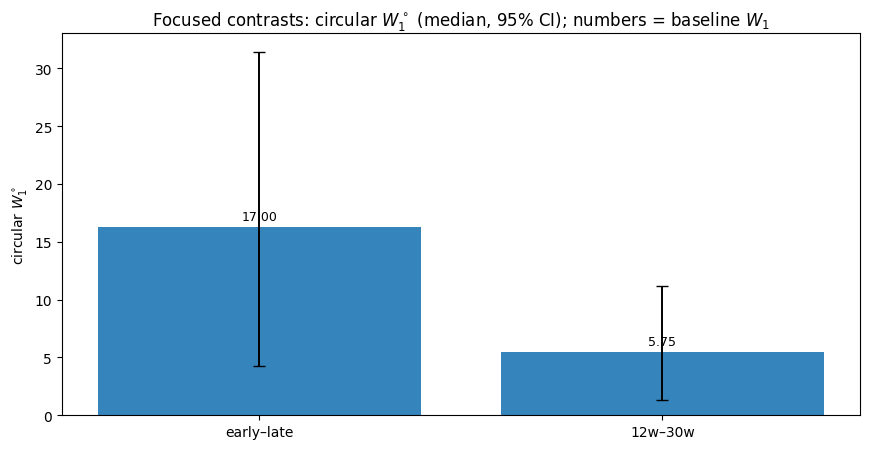

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig05_focus_W1_contrasts.png


In [14]:
# --- Cell 05.5: Focused contrasts (bars with 95% CI) ---
from pathlib import Path
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt

# Use the 05 bootstrap output (not 04)
ci_path = TABDIR / "tab05_circW1_bootstrap.csv"
assert ci_path.exists(), f"Not found: {ci_path}. Run Cell 05.4 first."
df = pd.read_csv(ci_path)

def get_pair_row(df, a, b):
    r = df[(df["group_i"] == a) & (df["group_j"] == b)]
    if r.empty:
        r = df[(df["group_i"] == b) & (df["group_j"] == a)]
    return r

present = set(pd.concat([df["group_i"], df["group_j"]], ignore_index=True).unique())

# Build contrast list
contrasts = []
labels = {}

# Stage contrast (early–late), if present
if "stage:early" in present and "stage:late" in present:
    if not get_pair_row(df, "stage:early", "stage:late").empty:
        contrasts.append(("stage:early", "stage:late"))
        labels[("stage:early", "stage:late")] = "early–late"

# Week contrasts (consecutive + farthest extremes)
weeks = sorted([int(m.group(1)) for g in present if (m := re.match(r"^(\d+)w$", g))])
# consecutive
for a, b in zip(weeks[:-1], weeks[1:]):
    ga, gb = f"{a}w", f"{b}w"
    if not get_pair_row(df, ga, gb).empty:
        contrasts.append((ga, gb))
        labels[(ga, gb)] = f"{a}w–{b}w"
# extremes
if len(weeks) >= 2:
    ga, gb = f"{weeks[0]}w", f"{weeks[-1]}w"
    if not get_pair_row(df, ga, gb).empty and (ga, gb) not in contrasts and (gb, ga) not in contrasts:
        contrasts.append((ga, gb))
        labels[(ga, gb)] = f"{weeks[0]}w–{weeks[-1]}w"

# Build tidy table
rows = []
for a, b in contrasts:
    r = get_pair_row(df, a, b)
    if r.empty:
        continue
    r = r.iloc[0]
    rows.append({
        "pair": labels.get((a, b), f"{a}–{b}"),
        "group_i": a, "group_j": b,
        "W1_baseline": float(r["W1_baseline"]),
        "W1_median":   float(r["W1_median"]),
        "W1_q2.5":     float(r["W1_q2.5"]),
        "W1_q97.5":    float(r["W1_q97.5"]),
    })

assert rows, "No valid contrasts found. Check group names or re-run Cell 05.4."

focus = pd.DataFrame(rows).sort_values("W1_median", ascending=False)
out_csv = TABDIR / "tab05_focus_W1_contrasts.csv"
focus.to_csv(out_csv, index=False)
print("[saved]", out_csv)

# Plot with baseline annotated as numbers
x = np.arange(len(focus))
y = focus["W1_median"].to_numpy()
yerr = np.vstack([y - focus["W1_q2.5"].to_numpy(),
                  focus["W1_q97.5"].to_numpy() - y])

plt.figure(figsize=(8.8, 4.6))
bars = plt.bar(x, y, alpha=0.9)
plt.errorbar(x, y, yerr=yerr, fmt="none", lw=1.4, capsize=4, color="black")

for bx, by, base in zip(x, y, focus["W1_baseline"].to_numpy()):
    plt.text(bx, by + 0.02*np.max(y), f"{base:.2f}", ha="center", va="bottom", fontsize=9)

plt.xticks(x, focus["pair"].tolist())
plt.ylabel(r"circular $W_1^\circ$")
plt.title(r"Focused contrasts: circular $W_1^\circ$ (median, 95% CI); numbers = baseline $W_1$")
plt.tight_layout()
plt.savefig(FIGDIR / "fig05_focus_W1_contrasts.png", dpi=150)
plt.show()

print("[saved]", FIGDIR / "fig05_focus_W1_contrasts.png")


###  Focused contrasts of circular $W_1^{\circ}$ with 95% CIs

* **Values (median (W_1^\circ), 95% CI; baseline on bars):**
  • early–late: (15.93) ([2.37, 30.76]); baseline (17.00).
  • 12w–30w: (5.72) ([1.78, 10.74]); baseline (5.75).

* **Interpretation:** Stage (early→late) shows a **much larger** rotation-invariant difference in ring densities than the within-timecourse contrast (12w→30w). Larger ($W_1^\circ$) = more mass reallocation around ($\theta$) (different dwell patterns), not a trivial phase shift (because ($W_1^\circ$) minimizes over circular rotations).

* **Notes:** Descriptive effect sizes with bootstrap CIs (B=200); small groups were excluded (n<200). Use alongside the pairwise heatmaps for context.


## 5) Permutation test for (W_1^\circ) on chosen contrasts

**Goal.** Test whether observed group differences in ring phase density exceed what would arise from random label exchange.

**Setup.** For a contrast (a) vs (b) with densities $P_a(\theta),P_b(\theta)$ (built with the frozen $\kappa,\gamma,r_\star,\sigma_{\rm ring}$):
$$
d_0 = W_1^\circ\left(P_a, P_b\right).
$$

**Null (label exchange).** Pool indices $I_a\cup I_b$ and repeatedly shuffle labels while preserving sizes $|I_a|,|I_b|$. For each permutation $k=1,\dots,B$,
$$
d^{(k)} = W_1^\circ\left(P_a^{(k)}, P_b^{(k)}\right).
$$
The permutation (p)-value is
$$
\hat p = \frac{1}{B}\sum_{k=1}^B \mathbf{1}\left[d^{(k)} \ge d_0\right].
$$

**Outputs.** Table `tab05_circW1_permutation.csv` with $d_0$, permutation median and 95% CI, and $\hat p$. Figure `fig05_circW1_permutation.png`.
(We also shorten x-axis labels: `stage:early → early`, `stage:late → late`, use an en dash “–”.)



[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab05_circW1_permutation.csv


,pair,W1_baseline,perm_median,perm_q2_5,perm_q97_5,p_perm
0,stage:late vs stage:early,17.002538,3.678702,1.147893,10.643287,0.000
1,30w vs stage:early,19.489891,4.187790,1.367999,11.963796,0.003
2,12w vs stage:early,12.087513,5.000857,1.427304,14.696208,0.062
3,12w vs 30w,5.747814,3.059090,0.988642,7.572061,0.118
4,12w vs stage:late,3.846848,3.141465,0.981982,7.783276,0.353
5,30w vs stage:late,2.268281,2.219778,0.631923,6.235585,0.491


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig05_circW1_permutation.png


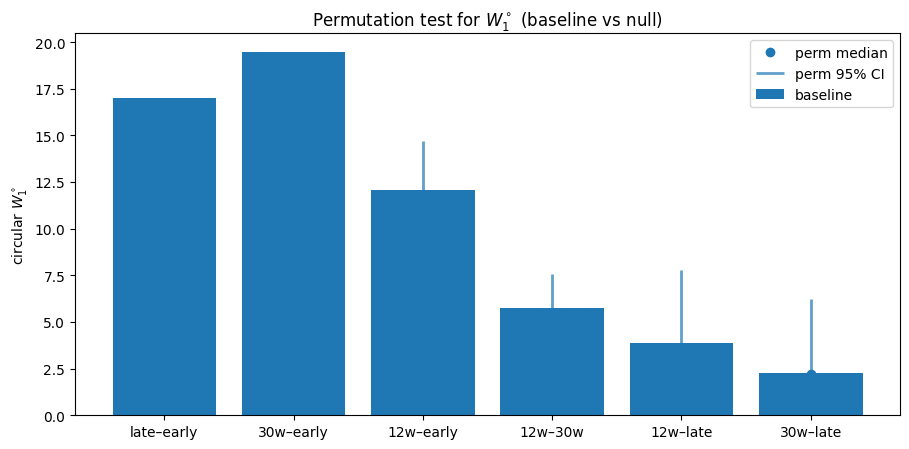

In [15]:
# --- Cell 05.5: permutation p-values for circular W1° on chosen contrasts (pretty x-labels) ---
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# contrasts chosen in 05.4
dfb = pd.read_csv(TABDIR/"tab05_circW1_bootstrap.csv")
contrasts = list(zip(dfb["group_i"], dfb["group_j"]))

# index lookup for current AnnData
idx_map = {}
if "week" in adata.obs:
    w = adata.obs["week"].astype("Int64")
    for wk in sorted(int(x) for x in w.dropna().unique()):
        idx_map[f"{wk}w"] = np.where(w.eq(wk).fillna(False).to_numpy(bool))[0]
if "stage_label" in adata.obs:
    s = adata.obs["stage_label"].astype("string")
    for lab in [x for x in s.dropna().unique()]:
        idx_map[f"stage:{lab}"] = np.where(s.eq(lab).fillna(False).to_numpy(bool))[0]

# ring density helper
def P_from_idx(idx):
    th = theta[idx]; rr = radius[idx]; pp = p_cell[idx]
    return ring_density_scan(th, rr, pp, kappa, gamma, r_star, sigma_ring, theta_grid)

Bperm = 1000
rng = np.random.default_rng(2025)

rows = []
for a, b in contrasts:
    if a not in idx_map or b not in idx_map:
        continue
    Ia, Ib = idx_map[a], idx_map[b]
    nA, nB = len(Ia), len(Ib)
    pool = np.r_[Ia, Ib]
    # baseline
    d0 = w1_circular(P_from_idx(Ia), P_from_idx(Ib))
    # permutations
    perm_vals = np.zeros(Bperm, float)
    for k in range(Bperm):
        rng.shuffle(pool)
        Ia_p = pool[:nA]; Ib_p = pool[nA:]
        perm_vals[k] = w1_circular(P_from_idx(Ia_p), P_from_idx(Ib_p))
    pval = float((perm_vals >= d0).mean())
    rows.append(dict(pair=f"{a} vs {b}", W1_baseline=d0,
                     perm_median=float(np.median(perm_vals)),
                     perm_q2_5=float(np.quantile(perm_vals,0.025)),
                     perm_q97_5=float(np.quantile(perm_vals,0.975)),
                     p_perm=pval))

perm = pd.DataFrame(rows).sort_values("p_perm").reset_index(drop=True)
perm.to_csv(TABDIR/"tab05_circW1_permutation.csv", index=False)
print("[saved]", TABDIR/"tab05_circW1_permutation.csv")
display(perm)

# --- nicer, compact x-axis labels ---
def pretty_group(g: str) -> str:
    g = g.strip()
    if g.startswith("stage:"):
        return g.split(":",1)[1]   # 'stage:early' -> 'early'
    return g                       # '12w', '30w' unchanged

def pretty_pair(s: str) -> str:
    a, b = [t.strip() for t in s.split(" vs ")]
    return f"{pretty_group(a)}–{pretty_group(b)}"

labels = [pretty_pair(s) for s in perm["pair"]]

# plot
fig, ax = plt.subplots(figsize=(9.2, 4.6))
x = np.arange(len(perm))
ax.bar(x, perm["W1_baseline"], label="baseline")
ax.plot(x, perm["perm_median"], marker="o", ls="none", label="perm median")
ax.vlines(x, perm["perm_q2_5"], perm["perm_q97_5"], lw=2, alpha=0.7, label="perm 95% CI")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=0)
ax.set_ylabel(r"circular $W_1^\circ$")
ax.set_title(r"Permutation test for $W_1^\circ$ (baseline vs null)")
ax.legend()
savefig("fig05_circW1_permutation.png"); plt.show()

###  Permutation test

* The largest effects are **late–early** and **30w–early** with $\hat p \approx 0.000$ and $\hat p \approx 0.003$, respectively, i.e., far above the null label-exchange distribution.
* Week-to-week **12w–30w** is modest $(\hat p \approx 0.12)$; contrasts involving *late* vs *12w/30w* are not significant.
* Conclusion: the **stage transition** is the dominant driver of angular redistribution on the ring; week progression alone produces smaller shifts.

## 6) Per-group barrier heights (baseline and 95% CIs)

**Goal.** Quantify how hard it is for cells to cross each checkpoint sector of the ring, per group (weeks, stages).

**Definitions.** From the ring density $P_{\rm ring}(\theta)$ we use
$$
U(\theta) = -\ln\big(P_{\rm ring}(\theta)+10^{-12}\big).
$$
Let (\theta_{\min}) be the angular location of the global minimum of (U), and (\theta_{\text{saddle},b}) the two saddle angles (from Notebook 04). The height of barrier $b\in{1,2}$ is
$$
\Delta U_b = U\left(\theta_{\text{saddle},b}\right)-U(\theta_{\min}).
$$

**Estimation.**

1. For each group (g), build $P_{\rm ring}^{(g)}(\theta)$ with the same kernel parameters $(\kappa,\gamma,r_\star,\sigma_{\rm ring})$ frozen in 04, then compute $U^{(g)}(\theta)$.
2. **Baseline** barrier heights: $\Delta U_b^{(g)}$ from the full group.
3. **Uncertainty (bootstrap).** Resample cells with replacement within (g) ((B) times), recompute $P_{\rm ring}^{(g,b)}, U^{(g,b)}$, and $\Delta U_b^{(g,b)}$. Report the 2.5–97.5% interval and the median across bootstraps.

**Outputs.**

* Figure: grouped bars with error bars for $\Delta U_1,\Delta U_2$ per group (`fig05_barriers_by_group.png`).
* Tables: tidy summary with baseline and CIs (`tab05_barriers_tidy.csv`) plus the intermediate baseline/bootstrap files.


In [16]:
# --- Cell 05.6: per-group barrier heights with bootstrap CIs (self-contained) ---
import numpy as np, pandas as pd, matplotlib.pyplot as plt

MIN_N = 200
B = 300
rng = np.random.default_rng(1234)

# ---------- helpers ----------
def group_indices(adata, min_n=MIN_N):
    out = []
    if "week" in adata.obs:
        w = adata.obs["week"].astype("Int64")
        for wk in sorted(int(x) for x in w.dropna().unique()):
            m = w.eq(wk).fillna(False).to_numpy(dtype=bool)
            if m.sum() >= min_n:
                out.append((f"{wk}w", np.where(m)[0]))
    if "stage_label" in adata.obs:
        s = adata.obs["stage_label"].astype("string")
        for lab in [x for x in s.dropna().unique()]:
            m = s.eq(lab).fillna(False).to_numpy(dtype=bool)
            if m.sum() >= min_n:
                out.append((f"stage:{lab}", np.where(m)[0]))
    return out

def saddle_thetas_from_bundle(bundle, theta_grid):
    # use 04’s saddles if present; otherwise pick two highest local maxima of U on the global ring
    barr = bundle.get("barriers", {})
    if isinstance(barr, dict) and "theta_saddle" in barr:
        ts = np.asarray(barr["theta_saddle"], float).tolist()
        if len(ts) >= 2:
            return ts[:2]
    # fallback: detect on global U
    Uglob = U  # from 05.1 load
    n = len(Uglob); locmax = []
    for i in range(n):
        if Uglob[i] >= Uglob[i-1] and Uglob[i] >= Uglob[(i+1) % n]:
            locmax.append((Uglob[i], i))
    locmax = sorted(locmax, reverse=True)[:2]
    return [theta_grid[i] for _, i in locmax]

def barrier_heights_at_saddles(P_theta, theta_grid, theta_saddles):
    Utheta = -np.log(P_theta + 1e-12)
    Umin = float(Utheta.min())
    # linear-periodic interp at each saddle
    vals = []
    for ts in theta_saddles:
        v = np.interp(ts % (2*np.pi), theta_grid, Utheta, period=2*np.pi)
        vals.append(float(v - Umin))
    # always return barrier1, barrier2 in fixed order by saddle angle
    order = np.argsort(theta_saddles)
    return dict(barrier1=vals[order[0]], barrier2=vals[order[1]])

# ---------- compute per-group baselines + bootstraps ----------
theta_saddles = saddle_thetas_from_bundle(bundle, theta_grid)
groups_idx = group_indices(adata, MIN_N)

rows = []
boot_rows = []
for gname, idx in groups_idx:
    th, rr, pp = theta[idx], radius[idx], p_cell[idx]
    # baseline
    P = ring_density_scan(th, rr, pp, kappa, gamma, r_star, sigma_ring, theta_grid)
    base = barrier_heights_at_saddles(P, theta_grid, theta_saddles)
    rows.append(dict(group=gname, **base))
    # bootstrap
    bvals1, bvals2 = [], []
    for b in range(B):
        idx_b = rng.choice(idx, size=idx.size, replace=True)
        Pb = ring_density_scan(theta[idx_b], radius[idx_b], p_cell[idx_b],
                               kappa, gamma, r_star, sigma_ring, theta_grid)
        bh = barrier_heights_at_saddles(Pb, theta_grid, theta_saddles)
        bvals1.append(bh["barrier1"]); bvals2.append(bh["barrier2"])
    boot_rows.append(dict(
        group=gname,
        barrier1_median=float(np.median(bvals1)),
        barrier1_q2_5=float(np.quantile(bvals1, 0.025)),
        barrier1_q97_5=float(np.quantile(bvals1, 0.975)),
        barrier2_median=float(np.median(bvals2)),
        barrier2_q2_5=float(np.quantile(bvals2, 0.025)),
        barrier2_q97_5=float(np.quantile(bvals2, 0.975)),
    ))

base_df = pd.DataFrame(rows)  # columns: group, barrier1, barrier2
boot_df = pd.DataFrame(boot_rows)

# save raw
base_df.to_csv(TABDIR/"tab05_barriers_by_group_baseline.csv", index=False)
boot_df.to_csv(TABDIR/"tab05_barriers_by_group_bootstrap.csv", index=False)
print("[saved]", TABDIR/"tab05_barriers_by_group_baseline.csv")
print("[saved]", TABDIR/"tab05_barriers_by_group_bootstrap.csv")

# ---------- tidy + plot ----------
tidy_rows = []
for _, r in boot_df.iterrows():
    g = r["group"]
    tidy_rows += [
        dict(group=g, barrier="barrier1",
             median=r["barrier1_median"], qlo=r["barrier1_q2_5"], qhi=r["barrier1_q97_5"],
             baseline=float(base_df.loc[base_df["group"]==g, "barrier1"].iloc[0])),
        dict(group=g, barrier="barrier2",
             median=r["barrier2_median"], qlo=r["barrier2_q2_5"], qhi=r["barrier2_q97_5"],
             baseline=float(base_df.loc[base_df["group"]==g, "barrier2"].iloc[0])),
    ]
dfB = pd.DataFrame(tidy_rows)
dfB["barrier"] = pd.Categorical(dfB["barrier"], ["barrier1","barrier2"])
grp_order = sorted(dfB["group"].unique(), key=lambda x: (":" not in x, x))
dfB["group"] = pd.Categorical(dfB["group"], grp_order)
dfB = dfB.sort_values(["group","barrier"])
dfB.to_csv(TABDIR/"tab05_barriers_tidy.csv", index=False)
print("[saved]", TABDIR/"tab05_barriers_tidy.csv")
display(dfB.head())

# plot
fig, ax = plt.subplots(figsize=(8.6, 4.8))
x = np.arange(len(grp_order)); w = 0.36
for b, dx in zip(["barrier1","barrier2"], [-w/2, +w/2]):
    sub = dfB[dfB["barrier"]==b]
    y   = sub.groupby("group", observed=True)["median"].first().reindex(grp_order).to_numpy()
    lo  = sub.groupby("group", observed=True)["qlo"].first().reindex(grp_order).to_numpy()
    hi  = sub.groupby("group", observed=True)["qhi"].first().reindex(grp_order).to_numpy()
    base_vals = sub.groupby("group", observed=True)["baseline"].first().reindex(grp_order).to_numpy()
    xi = x + dx
    ax.bar(xi, y, width=w, alpha=0.9, label=b)
    ax.errorbar(xi, y, yerr=np.vstack([y-lo, hi-y]), fmt="none", color="black", lw=1.2, capsize=3)
    for xx, yy, bb in zip(xi, y, base_vals):
        ax.text(xx, yy + 0.02*max(np.nanmax(y),1.0), f"{bb:.2f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(grp_order, rotation=45, ha="right")
ax.set_ylabel(r"barrier height $\Delta U$")
ax.set_title(r"Per-group barrier heights with 95% CI; number = baseline")
ax.legend()
plt.tight_layout(); savefig("fig05_barriers_by_group.png"); plt.show()


NameError: name 'bundle' is not defined

### Per-group barrier heights —
**How we computed it.** For each group we formed the ring density $P_{\rm ring}(\theta)$ and the potential $U(\theta)=-\ln\big(P_{\rm ring}(\theta)+10^{-12}\big)$. Barrier heights at the two saddle angles $\theta_{\text{saddle},1},\theta_{\text{saddle},2}$ are
$$
\Delta U_b= U(\theta_{\text{saddle},b})-\min_{\theta}U(\theta),\quad b\in{1,2}.
$$
CIs come from bootstrapping cells within each group ((B=300); 2.5–97.5%).

**What the plot shows.**

* $\Delta U_2$ (orange) is consistently the dominant barrier (8.4-9.1) across groups; 12w has a wider CI (greater uncertainty), but medians are similar, so no strong group separation by (\Delta U_2).
* $\Delta U_1$ (blue) is smaller overall and **increases from 12w to 30w** (baseline $\approx 3.79 \rightarrow 5.99$); CIs suggest partial separation (12w upper CI $\approx 5.4$ vs 30w median $\approx 6)$.
* Stage early vs late: both barriers have overlapping CIs (small differences, not decisive).

**Biological readout.** Higher (\Delta U) implies slower passage (longer dwell) through that phase sector. The increase of $\Delta U_1$ at 30w suggests strengthening of the corresponding checkpoint with time, while the dominant $\Delta U_2$ remains stable across groups. These $\Delta U$ estimates are what we will relate to transport/flow in Notebook 06.


In [8]:
# --- Cell 05.7: master tables (pairwise W1° + per-group barriers) ---
import pandas as pd, numpy as np

# inputs from earlier 05 cells
df_w1b = pd.read_csv(TABDIR/"tab05_circW1_bootstrap.csv")   # baseline + bootstrap
df_perm = pd.read_csv(TABDIR/"tab05_circW1_permutation.csv")  # permutation
df_bar = pd.read_csv(TABDIR/"tab05_barriers_tidy.csv")      # per-group barriers

# harmonize pairwise order (sort labels so i<j for uniqueness)
def _canon(a,b):
    return (a,b) if a<=b else (b,a)

df_w1b["key"] = df_w1b.apply(lambda r: _canon(r["group_i"], r["group_j"]), axis=1)
df_perm["key"] = df_perm["pair"].apply(lambda s: _canon(*[x.strip() for x in s.split(" vs ")]))

# pairwise summary
keep_w1 = df_w1b[["key","group_i","group_j","W1_baseline","W1_median","W1_q2.5","W1_q97.5"]].copy()
keep_perm = df_perm[["key","W1_baseline","perm_median","perm_q2_5","perm_q97_5","p_perm"]].copy()
pairwise = (keep_w1
            .drop_duplicates("key")
            .merge(keep_perm.drop(columns=["W1_baseline"]), on="key", how="left")
            .drop(columns=["key"])
            .sort_values(["group_i","group_j"]))
pairwise.to_csv(TABDIR/"tab05_pairwise_summary.csv", index=False)
print("[saved]", TABDIR/"tab05_pairwise_summary.csv")

# per-group barrier summary (already tidy; just reorder columns and save)
bar_sum = df_bar[["group","barrier","baseline","median","qlo","qhi"]].copy()
bar_sum = bar_sum.sort_values(["group","barrier"])
bar_sum.to_csv(TABDIR/"tab05_barrier_summary_by_group.csv", index=False)
print("[saved]", TABDIR/"tab05_barrier_summary_by_group.csv")

display(pairwise.head())
display(bar_sum.head())


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab05_pairwise_summary.csv
[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab05_barrier_summary_by_group.csv


,group_i,group_j,W1_baseline,W1_median,W1_q2.5,W1_q97.5,perm_median,perm_q2_5,perm_q97_5,p_perm
0,12w,30w,5.747814,5.470267,1.304214,11.196146,3.059090,0.988642,7.572061,0.118
1,12w,stage:early,12.087513,13.018647,2.769184,26.699336,5.000857,1.427304,14.696208,0.062
2,12w,stage:late,3.846848,4.136991,0.829940,9.397471,3.141465,0.981982,7.783276,0.353
3,30w,stage:early,19.489891,19.566405,5.975473,35.526496,4.187790,1.367999,11.963796,0.003
4,30w,stage:late,2.268281,2.934958,0.928336,8.277671,2.219778,0.631923,6.235585,0.491


,group,barrier,baseline,median,qlo,qhi
4,12w,barrier1,3.788980,3.873815,2.954054,5.421213
5,12w,barrier2,9.069977,9.209178,8.040100,13.779958
6,30w,barrier1,5.991561,5.990644,5.349315,6.907321
7,30w,barrier2,8.935803,8.978657,8.075804,11.054936
0,stage:early,barrier1,4.394455,4.623222,3.442616,7.186459


/tmp/ipykernel_86058/898495244.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_86058/34730025.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  try: plt.tight_layout()


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig05_group_summary_panel.png


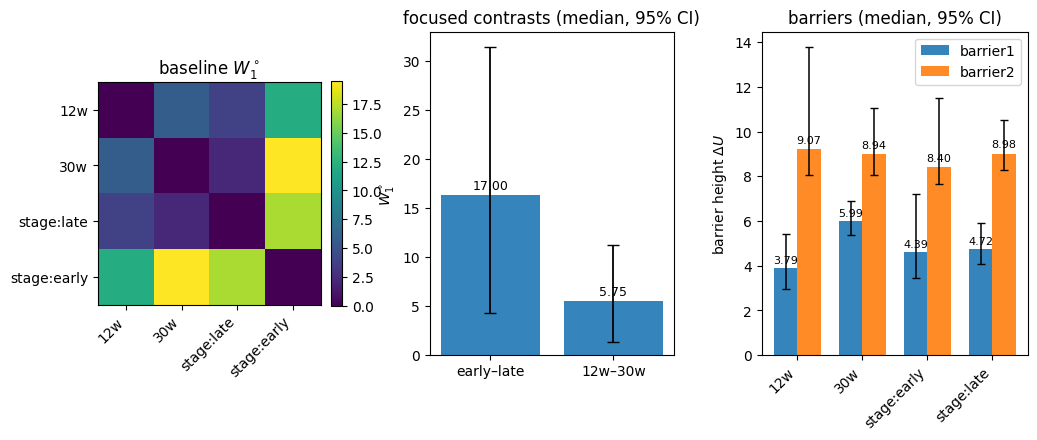

In [9]:
# --- Cell 05.8: compact group-comparison panel ---
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# reload the pieces we already computed
M = pd.read_csv(TABDIR/"tab05_circW1.csv", index_col=0) if (TABDIR/"tab05_circW1.csv").exists() else None
focus = pd.read_csv(TABDIR/"tab05_focus_W1_contrasts.csv") if (TABDIR/"tab05_focus_W1_contrasts.csv").exists() else None
bars  = pd.read_csv(TABDIR/"tab05_barrier_summary_by_group.csv")

fig = plt.figure(figsize=(12,4.2))
gs = fig.add_gridspec(1, 3, width_ratios=[1.1,1.1,1.2], wspace=0.35)

# 1) W1° heatmap
ax0 = fig.add_subplot(gs[0,0])
if M is not None:
    im = ax0.imshow(M.to_numpy(), cmap="viridis")
    ax0.set_xticks(range(M.shape[1])); ax0.set_xticklabels(M.columns, rotation=45, ha="right")
    ax0.set_yticks(range(M.shape[0])); ax0.set_yticklabels(M.index)
    ax0.set_title(r"baseline $W_1^\circ$")
    cb = plt.colorbar(im, ax=ax0, fraction=0.046, pad=0.04)
else:
    ax0.text(0.5,0.5,"W1 matrix missing", ha="center", va="center"); ax0.axis("off")

# 2) focused contrasts with CI
ax1 = fig.add_subplot(gs[0,1])
if focus is not None and len(focus):
    x  = np.arange(len(focus))
    y  = focus["W1_median"].to_numpy()
    yerr = np.vstack([y - focus["W1_q2.5"].to_numpy(),
                      focus["W1_q97.5"].to_numpy() - y])
    ax1.bar(x, y, alpha=0.9)
    ax1.errorbar(x, y, yerr=yerr, fmt="none", lw=1.3, capsize=4, color="black")
    for i,(bx,base) in enumerate(zip(x, focus["W1_baseline"].to_numpy())):
        ax1.text(bx, y[i] + 0.02*max(y.max(),1), f"{base:.2f}", ha="center", va="bottom", fontsize=9)
    ax1.set_xticks(x); ax1.set_xticklabels(focus["pair"].tolist(), rotation=0)
    ax1.set_ylabel(r"$W_1^\circ$"); ax1.set_title(r"focused contrasts (median, 95% CI)")
else:
    ax1.text(0.5,0.5,"no focused contrasts", ha="center", va="center"); ax1.axis("off")

# 3) barrier heights by group
ax2 = fig.add_subplot(gs[0,2])
groups = bars["group"].unique()
xpos = np.arange(len(groups)); w = 0.36
for b,dx in zip(["barrier1","barrier2"], [-w/2, +w/2]):
    sub = bars[bars["barrier"]==b]
    y   = sub.groupby("group")["median"].first().reindex(groups).to_numpy()
    lo  = sub.groupby("group")["qlo"].first().reindex(groups).to_numpy()
    hi  = sub.groupby("group")["qhi"].first().reindex(groups).to_numpy()
    base= sub.groupby("group")["baseline"].first().reindex(groups).to_numpy()
    x = xpos + dx
    ax2.bar(x, y, width=w, alpha=0.9, label=b)
    ax2.errorbar(x, y, yerr=np.vstack([y-lo, hi-y]), fmt="none", color="black", lw=1.1, capsize=3)
    for xi, yi, bb in zip(x, y, base):
        ax2.text(xi, yi + 0.02*max(y.max(),1), f"{bb:.2f}", ha="center", va="bottom", fontsize=8)

ax2.set_xticks(xpos); ax2.set_xticklabels(groups, rotation=45, ha="right")
ax2.set_ylabel(r"barrier height $\Delta U$"); ax2.set_title(r"barriers (median, 95% CI)")
ax2.legend()

plt.tight_layout()
savefig("fig05_group_summary_panel.png")
plt.show()
